### Contents

1 Import libraries and dataset  
2 Hypothesis  
3 Linear regression

### 1 Import libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
%matplotlib inline

In [6]:
path = r"C:\Users\cathe\OneDrive\Data Analysis\2 6 Schools in England and Wales\02 Data\Prepared Data"

In [8]:
df = pd.read_csv(os.path.join(path, "complete_data_v2.csv"))

In [19]:
df.columns

Index(['Unnamed: 0', 'URN', 'Ofsted phase', 'School open date',
       'Admissions policy', 'Sixth form', 'Region', 'Local authority',
       'Postcode', 'IDACI quintile', 'Total pupils',
       'Inspection number of latest graded inspection', 'Inspection type',
       'Inspection type grouping', 'Inspection start date', 'Publication date',
       'School type at time of latest graded inspection', 'OE', 'QE', 'BA',
       'PD', 'LM', 'Previous graded inspection number',
       'Previous inspection start date', 'Previous publication date',
       'School type at time of previous graded inspection', 'Previous OE',
       'Previous QE', 'Previous BA', 'Previous PD', 'Previous LM',
       'LA Total Pop', 'LA 0-3yo', 'LA 4-10yo', 'LA 11-17yo', 'LA under 18s',
       'LA Pop Density'],
      dtype='object')

### 2 Hypothesis

In [15]:
# Scatterplot for population density and income deprivation quintile

sns.lmplot(x = 'LA Pop Density', y = 'IDACI quintile', data = df)

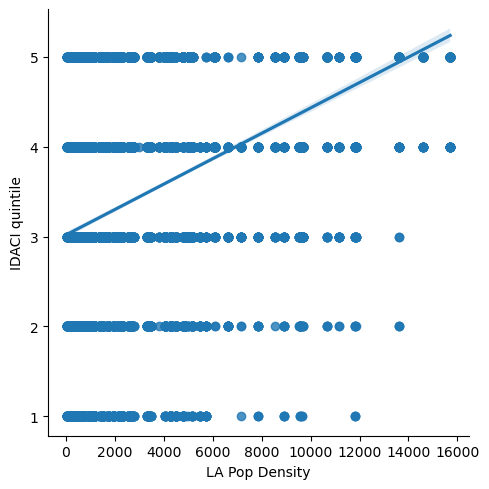

In [23]:
plt.show()

Hypothesis: The higher the population density in the local authority, the higher the IDACI quintile

### 3 Linear Regression

In [28]:
# Reshape the variables into NumPy arrays and put them into separate objects

X = df['LA Pop Density'].values.reshape(-1,1)
y = df['IDACI quintile'].values.reshape(-1,1)

In [30]:
# Split data into training set and test set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [32]:
# Create regression object

regression = LinearRegression()

In [34]:
# Fit regression object onto the training set

regression.fit(X_train, y_train)

LinearRegression()

In [36]:
# Create prediction for y on the test set

y_predicted = regression.predict(X_test)

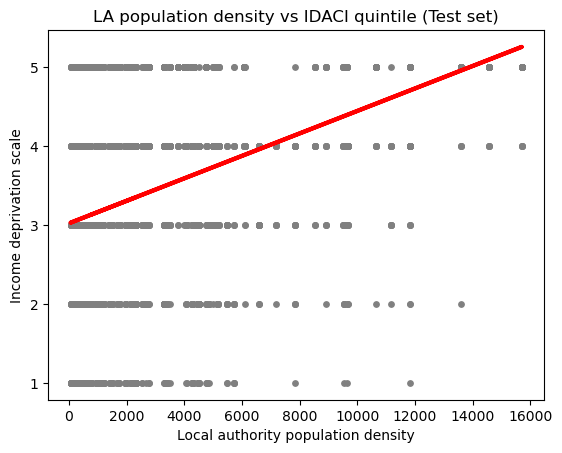

In [38]:
# Create a plot that shows the regression line from the model on the test set.

plot_test = plt
plot_test.scatter(X_test, y_test, color='gray', s = 15)
plot_test.plot(X_test, y_predicted, color='red', linewidth =3)
plot_test.title('LA population density vs IDACI quintile (Test set)')
plot_test.xlabel('Local authority population density')
plot_test.ylabel('Income deprivation scale')
plot_test.show()

The line does not fit the data particularly well, as expected from the correlation coefficient of 0.32 between the two variables.

In [43]:
# Create model performance statistics

rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted) 

In [45]:
# Print performance statistics

print('Mean squared error: ', rmse)
print('R2 score: ', r2)

Mean squared error:  1.7643320840171197
R2 score:  0.09521797785119623


Mean squared error doesn't look bad by itself, but r2 score is very close to zero!

In [48]:
# Create a dataframe comparing the actual and predicted values of y.

data = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_predicted.flatten()})
data.head(30)

,Actual,Predicted
0,3.0,3.139288
1,3.0,3.238644
2,3.0,3.355421
3,4.0,3.189572
4,2.0,3.338954
5,1.0,3.102851
6,4.0,3.167692
7,2.0,3.232832
8,5.0,3.265424
9,4.0,3.051741


There is a lot of variation in these results between the actual and the predicted IDACI figures.  It is possible that regression analysis is not particularly suitable when one variable can only take 5 values.  Also, I think that the IDACI quintile, although related to population density, has many other contributing factors which would need to be added in to form a good predictive model.